In [94]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import scipy
import sklearn
from sklearn.svm import SVC
from scipy.stats import pearsonr
from sklearn import datasets, linear_model
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, cross_val_score,  
    RepeatedStratifiedKFold, 
    RandomizedSearchCV,
    train_test_split, 
    KFold
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    f1_score
)
from sklearn.feature_selection import SelectFromModel
from sklearn.compose import ColumnTransformer
from scipy.stats import loguniform

#!pip install xlrd 
#!pip install category_encoders
import category_encoders as ce



In [95]:
df = pd.read_excel("TrainDataset2025.xls")
df.head()

,ID,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,TRG002174,1,144.0,41.0,0,0,0,1,3,3,...,0.517172,0.375126,3.325332,0.002314,3880771.500,473.464852,0.000768,0.182615,0.030508,0.000758
1,TRG002178,0,142.0,39.0,1,1,0,0,3,3,...,0.444391,0.444391,3.032144,0.005612,2372009.744,59.459710,0.004383,0.032012,0.001006,0.003685
2,TRG002204,1,135.0,31.0,0,0,0,1,2,1,...,0.534549,0.534549,2.485848,0.006752,1540027.421,33.935384,0.007584,0.024062,0.000529,0.006447
3,TRG002206,0,12.0,35.0,0,0,0,1,3,3,...,0.506185,0.506185,2.606255,0.003755,6936740.794,46.859265,0.005424,0.013707,0.000178,0.004543
4,TRG002210,0,109.0,61.0,1,0,0,0,2,1,...,0.462282,0.462282,2.809279,0.006521,1265399.054,39.621023,0.006585,0.034148,0.001083,0.005626


In [33]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 121 entries, ID to original_ngtdm_Strength
dtypes: float64(108), int64(12), object(1)
memory usage: 378.3+ KB


,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,HistologyType,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,...,4.000000e+02,4.000000e+02,4.000000e+02,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000
mean,12.697500,56.000208,51.804674,0.547500,2.902500,2.797500,2.830000,9.875000,6.562500,8.63250,...,3.957637e-01,3.911005e-01,2.722189e+00,0.003347,5.679717e+07,178.311246,32500.032620,0.056935,0.005965,0.029322
std,111.107417,27.137584,10.948522,0.498362,49.932114,49.937068,49.935558,86.092911,70.444284,86.20034,...,1.666319e-01,1.615922e-01,7.648849e-01,0.002419,7.063846e+08,1045.453432,177545.921568,0.047179,0.008379,0.115915
min,0.000000,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,...,7.050000e-11,7.050000e-11,-3.200000e-16,0.000008,0.000000e+00,0.000000,0.000248,0.000000,0.000000,0.000000
25%,0.000000,38.000000,44.516769,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,3.199017e-01,3.184398e-01,2.340783e+00,0.001389,1.030473e+06,18.760570,0.001826,0.018628,0.000310,0.001464
50%,0.000000,55.000000,51.019507,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,4.095627e-01,4.054695e-01,2.814884e+00,0.002944,3.277334e+06,67.929659,0.004383,0.047740,0.002330,0.003276
75%,0.000000,73.000000,60.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.00000,...,5.000049e-01,4.956920e-01,3.304411e+00,0.004798,9.079686e+06,157.370294,0.013769,0.085321,0.007962,0.009479
max,999.000000,144.000000,79.603012,1.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000,...,8.773779e-01,8.571429e-01,4.947427e+00,0.011301,1.390001e+10,20764.693790,1000000.000000,0.285100,0.060742,1.145601


In [34]:
df.replace(999, pd.NA, inplace=True)

In [37]:
# Get columns with missing values
missing_cols = df.columns[df.isna().any()]

# Missing data summary before droppig "pCR" missing values rows and "RelapseFreeSurvival" column
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df[col].isna().sum() for col in missing_cols],
    'Dtype': [df[col].dtype for col in missing_cols]
})

summary

,Column,MissingCount,Dtype
0,pCR (outcome),5,object
1,PgR,1,object
2,HER2,1,object
3,TrippleNegative,1,object
4,ChemoGrade,3,object
5,Proliferation,2,object
6,HistologyType,3,object
7,LNStatus,1,object
8,Gene,88,object


In [38]:
df_dropped =  df.dropna(subset=['pCR (outcome)'])
df_dropped = df_dropped.drop("RelapseFreeSurvival (outcome)", axis=1)
df_dropped.shape

(395, 120)

In [39]:
missing_cols = df_dropped.columns[df_dropped.isna().any()]
# Missing data summary
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df_dropped[col].isna().sum() for col in missing_cols],
    'Dtype': [df_dropped[col].dtype for col in missing_cols]
})

print(summary)

            Column  MissingCount   Dtype
0              PgR             1  object
1             HER2             1  object
2  TrippleNegative             1  object
3       ChemoGrade             3  object
4    Proliferation             2  object
5    HistologyType             3  object
6         LNStatus             1  object
7             Gene            85  object


In [82]:
# Iterative imputation

df_imputed = df_dropped.copy()

# Select categorical columns
cat_columns = df_imputed.select_dtypes(include=['object', 'category']).columns
cat_cols_to_encode = cat_columns.drop('pCR (outcome)')

encoder = ce.OrdinalEncoder(handle_missing='return_nan') 


# Encode categorical features
df_imputed[cat_cols_to_encode] = encoder.fit_transform(df_imputed[cat_cols_to_encode])


## Imputation with IterativeImputer
y_target = df_imputed['pCR (outcome)']
X_features = df_imputed.drop(columns=['pCR (outcome)'])

# Iterative Imputer
imputer = IterativeImputer(max_iter=20, random_state=42)
X_imputed = imputer.fit_transform(X_features)

# Convert back to DataFrame
X_imputed_df = pd.DataFrame(X_imputed,
                            columns=X_features.columns,
                            index=X_features.index)

# Round encoded categorical columns back to integers
for col in cat_cols_to_encode:
    max_val = df_imputed[col].max()
    min_val = df_imputed[col].min()
    X_imputed_df[col] = X_imputed_df[col].clip(lower=min_val, upper=max_val)
    X_imputed_df[col] = X_imputed_df[col].round().astype(int)

    
# Inverse transform encoded categorical columns
X_imputed_df[cat_cols_to_encode] = encoder.inverse_transform(X_imputed_df[cat_cols_to_encode])


# Recombine target
final_df = pd.concat([X_imputed_df, y_target], axis=1)
final_df = final_df[sorted(final_df.columns)]
print("\n--- Missing Value Check ---")
print(final_df.isna().sum().sum())


--- Missing Value Check ---
0


In [105]:
# Preprocessing

y = final_df["pCR (outcome)"].astype(int)
X = final_df.drop(["pCR (outcome)", "ID"], axis=1)

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Train/Val/Test Split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,        
    stratify=y_temp,
    random_state=42,
)

keep_cats = ["Gene", "HER2", "ER"] # categoricals features that must not be dropped by the feature selector
other_cats = [c for c in cat_features if c not in keep_cats]

# Separate proprocessing for important and other features
keep_preprocess = ColumnTransformer( # does not need scaling
    transformers=[
        ("keep_cat", OneHotEncoder(handle_unknown="ignore"), keep_cats),
    ],
    remainder="drop"
)

other_preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), other_cats),
    ],
    remainder="drop"
)

rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ),
    threshold="median", # mean, median performs better
)


In [106]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestClassifier

class RFPercentileSelector(BaseEstimator, TransformerMixin):
    """
    Select features whose RandomForest importance is above a given percentile.
    Works as a drop-in transformer inside a Pipeline.
    """
    def __init__(
        self,
        percentile=50,
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ):
        self.percentile = percentile
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.class_weight = class_weight

    def fit(self, X, y):
        # Train RF on the *preprocessed* matrix X
        self.rf_ = RandomForestClassifier(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            n_jobs=self.n_jobs,
            random_state=self.random_state,
            class_weight=self.class_weight,
        )
        self.rf_.fit(X, y)

        importances = self.rf_.feature_importances_
        self.threshold_ = np.percentile(importances, self.percentile)
        self.mask_ = importances >= self.threshold_

        # For compatibility with some sklearn utilities
        self.feature_importances_ = importances
        return self

    def transform(self, X):
        return X[:, self.mask_]


In [107]:
# Features = [ER/HER2/Gene one-hot] + [RF-selected other features]
full_features = FeatureUnion([
    ("always_keep", keep_preprocess),
    ("rf_selected", Pipeline([
        ("prep", other_preprocess),
        #("select", rf_selector),
        ("select", RFPercentileSelector(percentile=50))
    ])),
])

svm_pipe = Pipeline(steps=[
    ("features", full_features),
    ("svm", SVC(kernel="rbf", probability=False)),
])

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42,
)

param_dist = {
    "svm__C": loguniform(1e-3, 1e3),
    "svm__gamma": loguniform(1e-4, 1e1),
    "svm__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42,
    verbose=1,
)


search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)

best_svm = search.best_estimator_


Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'svm__C': 43.00001586162607, 'svm__class_weight': 'balanced', 'svm__gamma': 0.002933870049164396}
Best CV ROC AUC: 0.7008990042674255


In [108]:
# Evaluation of Model
# Fit best pipeline on training set
best_svm.fit(X_train, y_train)

# Decision scores on test set
scores_val = best_svm.decision_function(X_val)  # continuous margins
y_pred_default = best_svm.predict(X_val)


In [109]:
def evaluate_thresholds(y_val, scores):
    """
    Returns optimal thresholds under multiple criteria
    and a full evaluation report.
    """

    # Get score-derived threshold sets
    fpr, tpr, roc_thr = roc_curve(y_val, scores)
    prec, rec, pr_thr = precision_recall_curve(y_val, scores)

    # Unique score thresholds
    unique_thr = np.unique(scores)

    # Combine all threshold candidates
    thresholds = np.unique(
        np.concatenate([roc_thr, pr_thr, unique_thr])
    )

    # Compute metrics per threshold
    results = []
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        bal_acc = 0.5 * (sens + spec)
        j_stat  = sens - (1 - spec)  # Youden's J = sensitivity + specificity − 1
        f1_pos = f1_score(y_val, y_pred, pos_label=1)
        results.append([thr, sens, spec, bal_acc, j_stat, f1_pos])

    results = pd.DataFrame(
        results,
        columns=["threshold", "sensitivity", "specificity", "balanced_acc", "youden_J", "f1_pos"]
    )

    # Pick optimal thresholds for balance accuracy and Youden's J
    best_bal = results.loc[results["balanced_acc"].idxmax()]
    best_J   = results.loc[results["youden_J"].idxmax()]
    best_f1 = results.loc[results["f1_pos"].idxmax()]

    print("\n===== OPTIMAL THRESHOLDS =====")
    print("\nBest Balanced Accuracy:")
    print(best_bal)

    print("\nBest Youden’s J:")
    print(best_J)
    
    print("\nBest F1 score")
    print(best_f1)

    # Plot curves
    plt.figure(figsize=(8,5))
    plt.plot(results["threshold"], results["sensitivity"], label="Sensitivity")
    plt.plot(results["threshold"], results["specificity"], label="Specificity")
    plt.plot(results["threshold"], results["balanced_acc"], label="Balanced Accuracy")
    plt.plot(results["threshold"], results["youden_J"], label="Youden’s J")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Metric")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return best_bal, best_J, results



===== OPTIMAL THRESHOLDS =====

Best Balanced Accuracy:
threshold       0.477133
sensitivity     0.588235
specificity     0.870968
balanced_acc    0.729602
youden_J        0.459203
f1_pos          0.571429
Name: 61, dtype: float64

Best Youden’s J:
threshold       0.477133
sensitivity     0.588235
specificity     0.870968
balanced_acc    0.729602
youden_J        0.459203
f1_pos          0.571429
Name: 61, dtype: float64

Best F1 score
threshold       0.477133
sensitivity     0.588235
specificity     0.870968
balanced_acc    0.729602
youden_J        0.459203
f1_pos          0.571429
Name: 61, dtype: float64


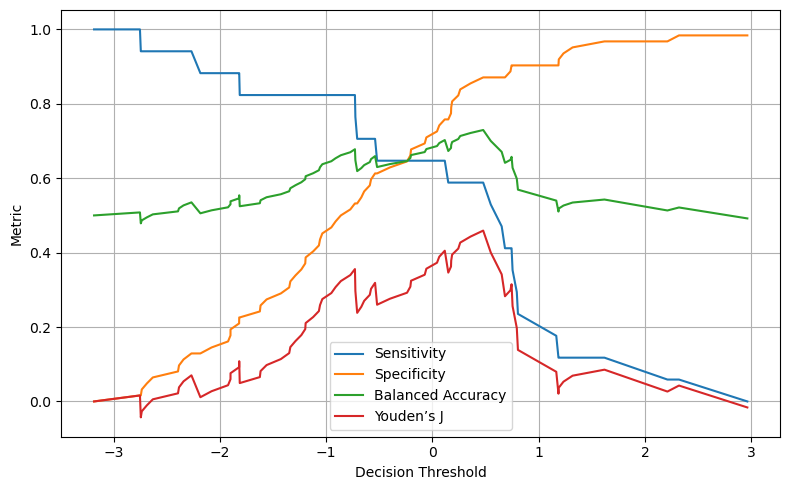

Chosen threshold (max balanced accuracy): 0.4771330527835261
Chosen threshold (max Youden's J): 0.4771330527835261

Validation performance at balanced-accuracy threshold
[[54  8]
 [ 7 10]]
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        62
           1       0.56      0.59      0.57        17

    accuracy                           0.81        79
   macro avg       0.72      0.73      0.72        79
weighted avg       0.81      0.81      0.81        79


Validation performance at Youden's J threshold
[[54  8]
 [ 7 10]]
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        62
           1       0.56      0.59      0.57        17

    accuracy                           0.81        79
   macro avg       0.72      0.73      0.72        79
weighted avg       0.81      0.81      0.81        79



In [110]:
best_bal, best_J, all_results = evaluate_thresholds(y_val, scores_val)
thr_bal = best_bal["threshold"]
thr_J = best_J["threshold"]

print("Chosen threshold (max balanced accuracy):", thr_bal)
print("Chosen threshold (max Youden's J):", thr_J)

y_val_pred_bal = (scores_val >= thr_bal).astype(int)
y_val_pred_J   = (scores_val >= thr_J).astype(int)

# validation performance at best thresholds
print("\nValidation performance at balanced-accuracy threshold")
print(confusion_matrix(y_val, y_val_pred_bal))
print(classification_report(y_val, y_val_pred_bal))

print("\nValidation performance at Youden's J threshold")
print(confusion_matrix(y_val, y_val_pred_J))
print(classification_report(y_val, y_val_pred_J))

In [89]:
# -----------------------------
# Evaluation on TEST set
# 

# Optionally refit on TRAIN + VAL to use more data for the final model
# X_train_full = pd.concat([X_train, X_val])
# y_train_full = pd.concat([y_train, y_val])

#best_svm.fit(X_train_full, y_train_full)

# Scores and default predictions on test
scores_test = best_svm.decision_function(X_test)
y_pred_default = best_svm.predict(X_test)

print("Test ROC AUC:", roc_auc_score(y_test, scores_test))
print("Test PR AUC:", average_precision_score(y_test, scores_test))
print("Test balanced accuracy (default 0.0 threshold):",
      balanced_accuracy_score(y_test, y_pred_default))
print("Confusion matrix (default threshold):")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default))

# Scores using tuned threshold with validation
print("\n=== Test performance at Youden's J threshold ===")
y_pred_J_test = (scores_test >= thr_J).astype(int)
print(confusion_matrix(y_test, y_pred_J_test))
print(classification_report(y_test, y_pred_J_test))

print("\n=== Test performance at balanced-accuracy threshold ===")
y_pred_bal_test = (scores_test >= thr_bal).astype(int)
print(confusion_matrix(y_test, y_pred_bal_test))
print(classification_report(y_test, y_pred_bal_test))


Test ROC AUC: 0.6688804554079697
Test PR AUC: 0.47378317278881704
Test balanced accuracy (default 0.0 threshold): 0.6356736242884251
Confusion matrix (default threshold):
[[46 16]
 [ 8  9]]
              precision    recall  f1-score   support

           0       0.85      0.74      0.79        62
           1       0.36      0.53      0.43        17

    accuracy                           0.70        79
   macro avg       0.61      0.64      0.61        79
weighted avg       0.75      0.70      0.71        79


=== Test performance at Youden's J threshold ===
[[62  0]
 [17  0]]
              precision    recall  f1-score   support

           0       0.78      1.00      0.88        62
           1       0.00      0.00      0.00        17

    accuracy                           0.78        79
   macro avg       0.39      0.50      0.44        79
weighted avg       0.62      0.78      0.69        79


=== Test performance at balanced-accuracy threshold ===
[[62  0]
 [17  0]]
           

C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Alonso\anaconda3